In [1]:
import sys
import time
import torch
import pybamm
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

[-1.14891765e+03  6.44025200e+03 -1.55588683e+04  2.11860429e+04
 -1.78633530e+04  9.66208361e+03 -3.36907238e+03  7.44974570e+02
 -1.00279728e+02  7.54862624e+00  3.44092384e+00]


Text(0, 0.5, 'SOC')

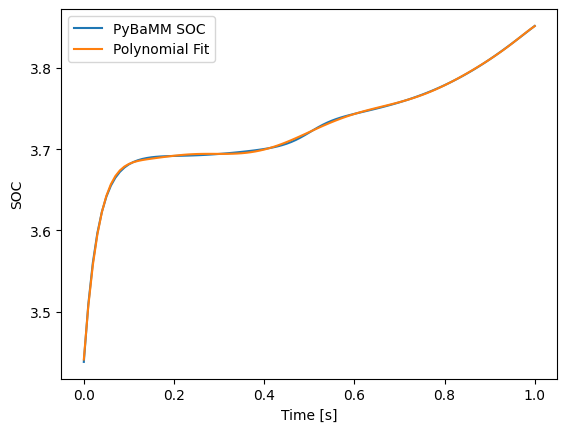

In [8]:
def simulate_pybamm():
    model = pybamm.lithium_ion.SPM()
    param = model.default_parameter_values
    
    # param["Current function [A]"] = my_current

    param.process_model(model)
    geometry = model.default_geometry
    param.process_geometry(geometry)
    mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)
    disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
    disc.process_model(model)
    t_eval = [0,3*3600]

    solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
    solution = solver.solve(model, t_eval)

    npc_v = solution.observe(model.variables['Voltage [V]'])
    npc = solution.observe(model.variables['Battery open-circuit voltage [V]'])
    npc_soc = solution.observe(model.variables['Average negative particle concentration'])
    npc_I = solution.observe(model.variables['Current variable [A]'])
    return solution,model, npc_v, npc, npc_soc, npc_I

def fit_func(solution, npc):
    t_ = np.linspace(0,solution['Time [s]'].entries[-1], 101)
    coeffs_ = np.polyfit(np.linspace(1,0,101), npc(t_), 10)  # Assumes pybamm soc [1, 0]
    poly = np.poly1d(coeffs_)  # Create polynomial function
    return poly, coeffs_, t_


solution, model, npc_v, npc, npc_soc, npc_I = simulate_pybamm()
poly, coeffs_, t_ = fit_func(solution, npc)
print(coeffs_)

soc_grid = np.linspace(1, 0, 101)
plt.plot(soc_grid, npc(t_), label='PyBaMM SOC')
plt.plot(soc_grid, poly(soc_grid), label='Polynomial Fit')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('SOC')